# Chapter 13: Hyperparameter Tuning with Optuna

**As the trial budget grows, how much of the search's reported improvement shows up on rows the search never used?**

The chapter says an HPO winner's score is not an independently assessed improvement. The size of the difference, and how it grows with the budget, tells you how much of a tuning report to believe.

*Constructed data and a stand-in learner and sampler. The reserved-row gain is small and noisy (it is below zero in some datasets, see the dots), and the optimism is a property of this 300-row generator, not a constant.*

## The experiment

A constructed binary task: 300 rows for the search and 4,000 rows reserved before it begins. A scikit-learn histogram gradient boosting model is tuned by random search (learning rate, leaves, leaf support, L2 and rounds) with 3-fold cross-validation, and the best configuration so far is refitted on the 300 rows and scored once on the reserved rows. Both are reported as gains over a fixed default configuration. The control is the number of trials; twelve independent datasets are averaged.

In [1]:
import numpy as np
from scipy.stats import rankdata
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold

from kaggle_companion.activities._common import clean

SEED = 13
REPLICATES = 12         # independent constructed datasets; every estimate is their mean
N_SEARCH, N_ASSESS = 300, 4000   # rows the search may use, and rows reserved before any search
BASELINE = dict(learning_rate=0.1, max_leaf_nodes=31, min_samples_leaf=20, l2_regularization=0.0, max_iter=100)


def generate(n, rng):
    """Ten numeric features: two main effects, an interaction, a bend and a threshold, plus noise."""
    X = rng.normal(size=(n, 10))
    logit = 0.9 * X[:, 0] - 0.7 * X[:, 1] + 0.6 * X[:, 2] * X[:, 3] + 0.5 * np.sin(2 * X[:, 4]) + 0.4 * (X[:, 5] > 0.5)
    y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
    return X, y


def sample_config(rng):
    """One random-search trial: learning rate, capacity, leaf support, regularization and rounds."""
    return dict(learning_rate=float(10 ** rng.uniform(-2, -0.3)), max_leaf_nodes=int(rng.integers(4, 32)),
                min_samples_leaf=int(rng.integers(3, 50)), l2_regularization=float(10 ** rng.uniform(-3, 1.5)),
                max_iter=int(rng.integers(10, 40)))


def roc_auc_score(y, score):
    """AUC as the rank (Mann-Whitney) statistic: the chance a random positive outscores a random negative. Same value as
    scikit-learn's roc_auc_score, computed directly because the search calls it hundreds of times."""
    ranks = rankdata(score)
    pos = y == 1
    n_pos, n_neg = pos.sum(), len(y) - pos.sum()
    return float((ranks[pos].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def model(config):
    return HistGradientBoostingClassifier(max_bins=32, random_state=0, **config)


def cv_auc(config, X, y, folds):
    """Development score of one configuration: mean AUC over the search folds."""
    return float(np.mean([roc_auc_score(y[v], model(config).fit(X[t], y[t]).predict_proba(X[v])[:, 1]) for t, v in folds]))


def assess(config, X, y, X_assess, y_assess):
    """Refit on all search rows and score once on the reserved rows."""
    return roc_auc_score(y_assess, model(config).fit(X, y).predict_proba(X_assess)[:, 1])


def run(trials):
    search_path, assess_path = [], []
    for rep in range(REPLICATES):
        rng = np.random.default_rng(SEED * 100 + rep)
        X, y = generate(N_SEARCH + N_ASSESS, rng)
        Xs, ys, Xa, ya = X[:N_SEARCH], y[:N_SEARCH], X[N_SEARCH:], y[N_SEARCH:]
        folds = list(StratifiedKFold(3, shuffle=True, random_state=0).split(Xs, ys))
        base_cv, base_assess = cv_auc(BASELINE, Xs, ys, folds), assess(BASELINE, Xs, ys, Xa, ya)
        best, gain_search, gain_assess = -1.0, [], []
        for _ in range(trials):
            config = sample_config(rng)
            score = cv_auc(config, Xs, ys, folds)
            if score > best:                       # a new best: freeze it and score it once on the reserved rows
                best, frozen = score, assess(config, Xs, ys, Xa, ya)
            gain_search.append(best - base_cv)      # what the search reports: best score so far minus the baseline's
            gain_assess.append(frozen - base_assess)  # what the frozen winner earns on reserved rows over the baseline
        search_path.append(gain_search)
        assess_path.append(gain_assess)
    s, a = np.array(search_path), np.array(assess_path)
    return clean({
        "trials": trials,
        "search_gain": float(s[:, -1].mean()), "assessment_gain": float(a[:, -1].mean()),
        "share_helped": float((a[:, -1] > 0).mean()),
        "mean_search_path": s.mean(axis=0), "mean_assessment_path": a.mean(axis=0),
        "assessment_path_per_replicate": a, "per_replicate_final": {"search": s[:, -1], "assessment": a[:, -1]},
        "replicates": REPLICATES, "search_rows": N_SEARCH, "assessment_rows": N_ASSESS,
    })


## Measure it across the control

The control is **search trials**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch13 import explain

VALUES = [1, 4, 8, 16]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                            1       4       8      16
Trials                      1       4       8      16
Search-reported gain   -0.007  +0.018  +0.027  +0.032
Gain on reserved rows  +0.000  +0.008  +0.011  +0.008
Optimism               -0.007   0.010   0.016   0.024
Datasets helped           50%     75%     83%     75%


## Look at it

The figure shows the default setting, search trials = 16.

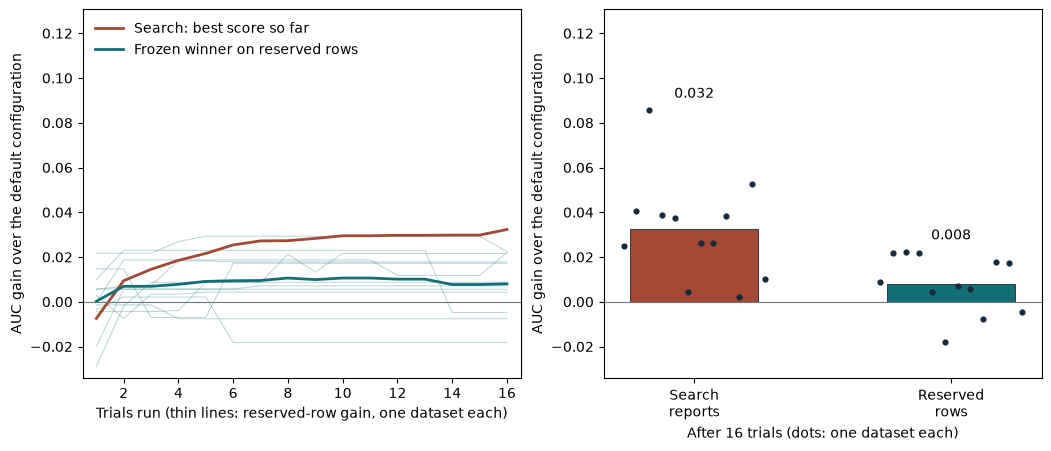

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch13 import draw, NCOLS, HEIGHT

DEFAULT = 16
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

After 16 trials the search reports a gain of +0.032 AUC over the default; the frozen winner earns +0.008 on 4,000 reserved rows, so 0.032 - 0.008 = 0.024 of the reported gain is optimism. The winner beat the default on reserved rows in 75% of the 12 datasets.

- Optimism: 0.032 - 0.008 = 0.024 AUC (search gain minus reserved-row gain).
- Share of the reported gain that carried over: 0.008 / 0.032 = 0.248.
- Datasets where the tuned winner beat the default on reserved rows: 75%.

## Apply this to your competition

- Reserve the assessment rows before the search, and refit the frozen best configuration on them exactly once.
- Report the gain over the untuned baseline on the reserved rows, next to the search's own best score and the elapsed cost.
- Treat a flat reserved-row gain as the signal to stop spending trials, even while the development score still rises.
- With little data, expect the development score to overstate the gain, and prefer coarse changes over many fine ones.

Book location: Chapter 13, The Optuna Pattern.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)